In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px
import numpy as np

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.parameter_adaptation import parameter_adaptation, cross_validated_parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import run_inference_algorithm_with_burn_in, posterior_function_draws, predictive_moments
from non_parametric_pro.data.synthetic.heteroskedastic import (
    heteroskedastic_noise_std,
    make_heteroskedastic_instance,
)
from non_parametric_pro.data.regime_switch import (
    make_regime_switch_instance
)

from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler
from scipy import stats

jax.config.update("jax_enable_x64", True)

In [ ]:
def _plot_regime_switch_case(ax, data):
    """
    Plot one RegimeSwitchCase: the single latent truth curve (no bands, no second
    branch -- it's an unambiguous, single-valued function throughout) and the noisy
    observed training points. Each region's span is lightly shaded so it's visible
    where the shorter-lengthscale (rougher) perturbation applies, since otherwise
    there's no color/branch cue the way there is for `_plot_multimodal_case`.
    """
    x_full = jnp.concatenate([data.x_train[:, 0], data.x_test[:, 0]])
    y_full = jnp.concatenate([data.y_truth_train[:, 0], data.y_truth_test[:, 0]])
    order = jnp.argsort(x_full)
    x_sorted, y_sorted = x_full[order], y_full[order]

    for center, width in zip(data.regions.centers, data.regions.widths, strict=True):
        ax.axvspan(float(center - width), float(center + width), color="C1", alpha=0.15, linewidth=0)

    ax.plot(x_sorted, y_sorted, color="C0", linewidth=1.5)
    ax.scatter(data.x_train, data.y_train, color="black", s=8, zorder=3)
    ax.set_title(
        f"$\\ell$={data.ell:.2f}  $\\ell_r$={data.ell_region:.2f}  $\\alpha$={data.alpha:.2f}",
        fontsize=9,
    )

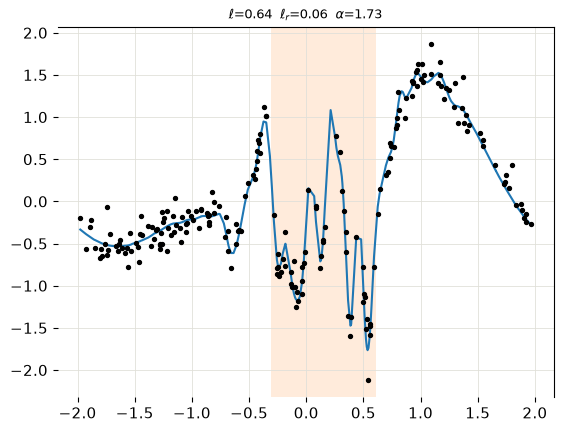

In [55]:
key = jr.PRNGKey(4)

example = make_regime_switch_instance(key, num_regions=1, ell_range=[0.5, 1.0], noise_std_frac=0.1, roughness_factor=10, n=300)

x_train, y_train = example.x_train, example.y_train
x_test, y_test = example.x_test, example.y_test

idx = np.argsort(x_test.squeeze())
x_test = x_test[idx]
y_test = y_test[idx]

fig, ax = plt.subplots()
_plot_regime_switch_case(ax, example)


In [56]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.RBF(lengthscale=0.3)

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
)

gp_latent_train_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_train_dist = gp_posterior.likelihood(gp_latent_train_dist)

gp_predictive_train_mean = gp_predictive_train_dist.mean
gp_predictive_train_std = jnp.sqrt(gp_predictive_train_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))
print("GP sigma", px.unwrap(gp_sigma))

Optimization terminated successfully.
         Current function value: 5.179987
         Iterations: 19
         Function evaluations: 25
         Gradient evaluations: 25
GP Train NLPD: -0.5821241875475367
GP Test NLPD: -0.36198273550911303
GP sigma 0.14787967778055083


In [57]:
print(px.unwrap(gp_kernel.lengthscale))
print(px.unwrap(gp_kernel.variance))

0.06542926603012504
0.45632047733408126


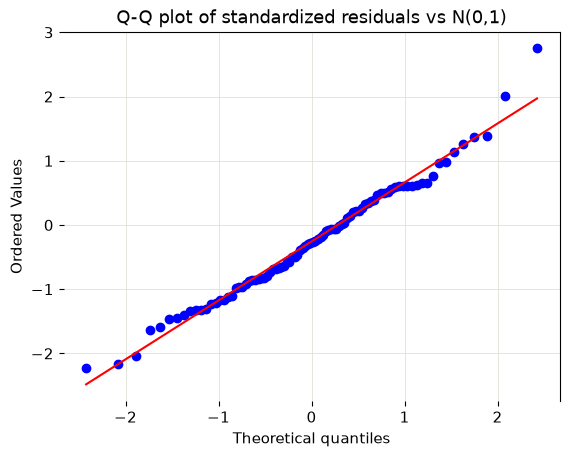

Shapiro-Wilk: 0.3676180471895372
Kolmogorov-Smirnov: 0.02252061710279718


In [58]:
residuals = (y_test.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

ks_stat, ks_pvalue = stats.kstest(residuals, "norm")

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)
print("Kolmogorov-Smirnov:", ks_pvalue)

In [89]:
num_particles = 30
sigma = gpx.parameters.SigmoidBounded(0.5, low=0.1, high=1.0)
lengthscale = gpx.parameters.SigmoidBounded(0.3, low=1.0e-3, high=1.0e3)
kernel = gpx.kernels.RBF(lengthscale=lengthscale)

pro_params = ProParameters(
    y=y_train,
    basis=None,
    step_size=0.0002,
    sigma=sigma,
    alpha=1.0,
)

adaptation = cross_validated_parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_full=x_train,
    y_full=y_train,
    initial_kernel=kernel,
    num_folds=1,
    val_fraction=0.3,
    num_particles=num_particles,
    num_steps=30000,
    warmup_steps=1000,
    sigma_adapt_steps=600,
    kernel_adapt_steps=350,
    objective_fn=pro_logdensity_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(0.05),
    progress_bar=True,
    rng_key=key
) 

Running parameter adaptation


<div><progress max="30000" value="30000"></progress> 100.00% [30000/30000 00:00&lt;?]</div>

In [90]:
print(adaptation.sigma)
print(adaptation.kernel.lengthscale)
print(adaptation.kernel.variance)

0.16776451024112446
0.17091988185365736
0.4864654518886551


In [91]:
adapted_kernel = adaptation.kernel
adapted_sigma = adaptation.sigma

k = adapted_kernel.gram(x_train).as_matrix()
basis_full = jnp.linalg.cholesky(k + 1e-6 * jnp.eye(k.shape[0]))

pro_params = pro_params._replace(basis=basis_full, sigma=adapted_sigma, alpha=1.0)

In [92]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)
num_steps = 30000

key, pos_key = jr.split(key)
initial_position = jr.normal(pos_key, (x_train.shape[0], num_particles))

key, sample_key = jr.split(key)
_, (states, info) = run_inference_algorithm_with_burn_in(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    initial_position=initial_position,
    num_steps=num_steps,
    burn_ratio=0.9,
    progress_bar=True,
)

<div><progress max="27000" value="27000"></progress> 100.00% [27000/27000 00:00&lt;?]</div>

<div><progress max="3000" value="3000"></progress> 100.00% [3000/3000 00:00&lt;?]</div>

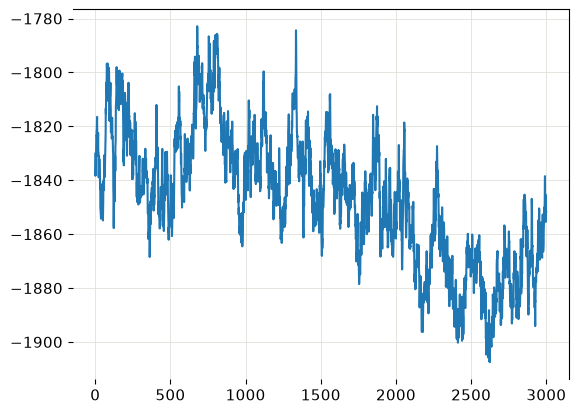

In [93]:
plt.plot(-info.score)
plt.show()

In [94]:
particles = states.position[::10]

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_train, pro_params
)

print("PRO Train NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))


test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

print("PRO Test NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.29473875755093093
PRO Test NLPD: -0.05714220644228451
GP Train NLPD: -0.5821241875475367
GP Test NLPD: -0.36198273550911303


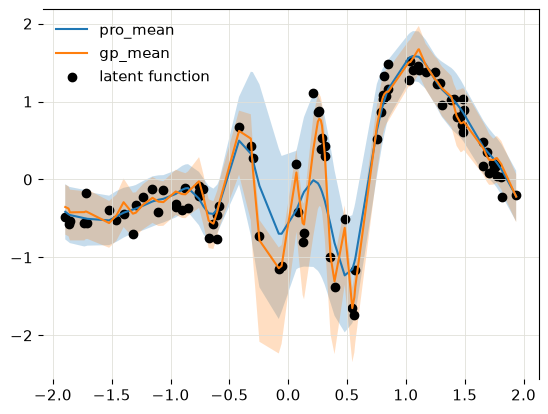

In [95]:
mean, std = predictive_moments(test_basis, particles, noise_std=adapted_sigma)

x_plot = x_test.squeeze()


plt.plot(x_plot, mean, label="pro_mean")
plt.plot(x_plot, gp_predictive_mean, label="gp_mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.25)
plt.scatter(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function")
plt.legend()
plt.show()

In [66]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=600,
    jitter=pro_params.jitter,
)

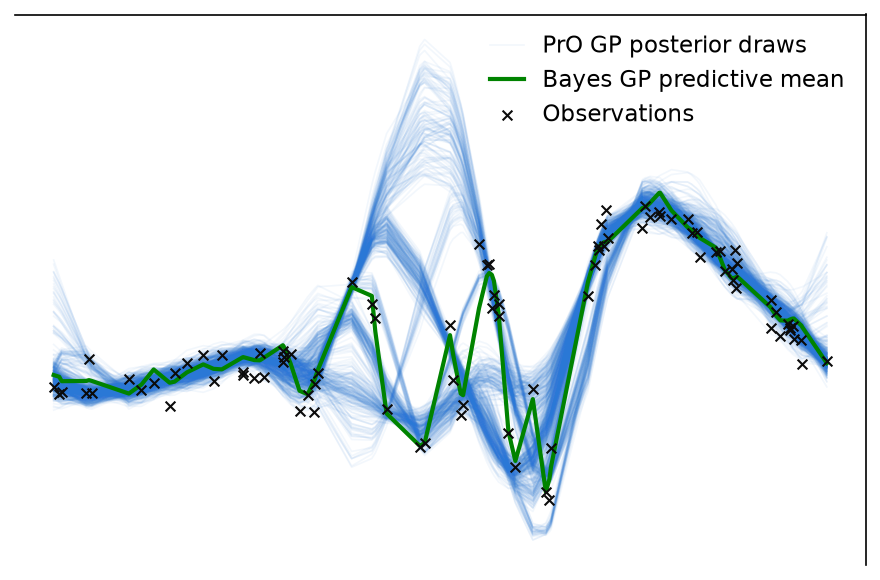

In [67]:

import numpy as np
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

draw_color = "#2a78d6"
mean_color = "#008300"
obs_color = "#0b0b0b"

order = np.argsort(x_test.squeeze())
x_sorted = x_test.squeeze()[order]
y_sorted = y_test.squeeze()[order]
mean_sorted = np.asarray(gp_predictive_mean).squeeze()[order]
draws_sorted = np.asarray(draws)[order]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_sorted, draws_sorted[:, 0], color=draw_color, alpha=0.06, linewidth=0.8,
        label="PrO GP posterior draws", rasterized=True)
ax.plot(x_sorted, draws_sorted[:, 1:], color=draw_color, alpha=0.06, linewidth=0.8,
        rasterized=True)
ax.plot(x_sorted, mean_sorted, color=mean_color, linewidth=2.0,
        label="Bayes GP predictive mean")
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0,
           label="Observations", zorder=5)

ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="best", handlelength=1.5)
fig.tight_layout()
plt.show()